# Comparación antes versus después de la Limpieza

**Autor:** Jazna Meza Hidalgo

**Correo Electrónico:** ja.meza@profesor.duoc.cl

**Fecha de Creación:** Marzo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook ofrece una comparación del antes y el después del proceso de limpieza de datos.

Además, se introduce el concepto de pipeline como buena práctica de la industria. En este caso se define un pipeline para el proceso de limpieza.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [ ]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/Programacion_para_ciencia_de_datos/master/data/dataset_notas_estudiantes.csv

--2026-03-19 15:19:48--  https://raw.githubusercontent.com/JaznaLaProfe/Programacion_para_ciencia_de_datos/master/data/dataset_notas_estudiantes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82547 (81K) [text/plain]
Saving to: ‘dataset_notas_estudiantes.csv’

dataset_notas_estud 100%[===================>]  80.61K  --.-KB/s    in 0.01s   

2026-03-19 15:19:48 (8.19 MB/s) - ‘dataset_notas_estudiantes.csv’ saved [82547/82547]



In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [ ]:
# Carga el set de datos
data = pd.read_csv('dataset_notas_estudiantes.csv')

## Revisión del estado

In [ ]:
# Cantidad de observaciones y columnas
data.shape

(1580, 8)

## Valores faltantes y tipos de datos

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1580 non-null   int64  
 1   programa           1580 non-null   object 
 2   genero             1453 non-null   object 
 3   colegio_origen     1452 non-null   object 
 4   asistencia_pct     1580 non-null   float64
 5   nota_matematicas   1457 non-null   float64
 6   nota_programacion  1452 non-null   float64
 7   nota_estadistica   1454 non-null   float64
dtypes: float64(4), int64(1), object(3)
memory usage: 98.9+ KB


## Existencia de duplicados

In [ ]:
# Revisa la existencia de duplicados
data.duplicated().sum()

np.int64(80)

In [ ]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='student_id')

,student_id,programa,genero,colegio_origen,asistencia_pct,nota_matematicas,nota_programacion,nota_estadistica
37,38,Ingeniería,No especifica,Particular,89.7,5.11,5.91,3.50
1537,38,Ingeniería,No especifica,Particular,89.7,5.11,5.91,3.50
1538,54,Diseño,M,Subvencionado,78.5,6.50,NaN,6.20
53,54,Diseño,M,Subvencionado,78.5,6.50,NaN,6.20
75,76,Data Science,No especifica,Municipal,69.4,4.97,5.72,3.11
...,...,...,...,...,...,...,...,...
1431,1432,Ingeniería,M,Subvencionado,82.7,4.87,6.92,5.10
1460,1461,Ingeniería,No especifica,Municipal,69.6,4.95,4.35,4.68
1548,1461,Ingeniería,No especifica,Municipal,69.6,4.95,4.35,4.68
1522,1465,Administración,M,Subvencionado,82.6,5.19,4.57,5.24


## Existencia de valores atípicos (outliers)

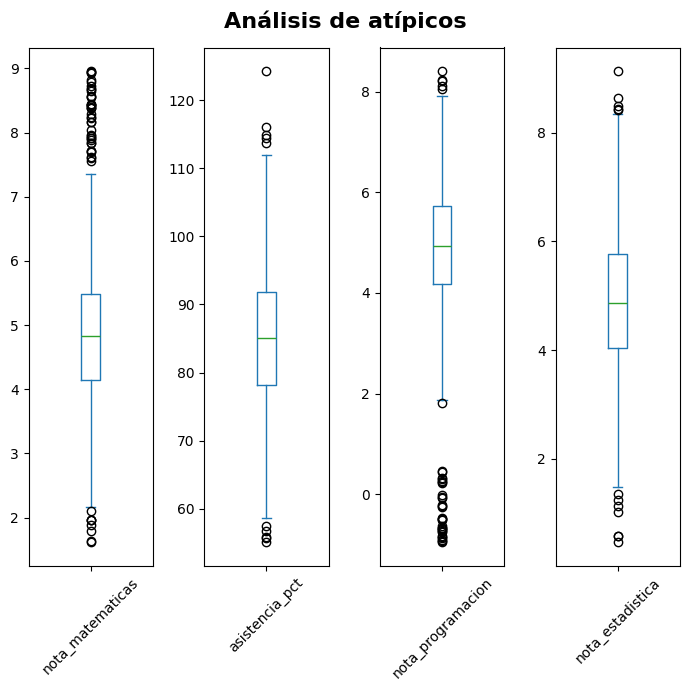

In [ ]:
revision_atipicos = ['nota_matematicas', 'asistencia_pct', 'nota_programacion',	'nota_estadistica']
fig, axes = plt.subplots(1, 4, figsize=(20,20))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Estadísticas antes de la limpieza

In [ ]:
# Muestra las medidas estadísticas, descartando la columna que identifica al estudiante
data.drop(columns=['student_id']).describe()

,asistencia_pct,nota_matematicas,nota_programacion,nota_estadistica
count,1580.000000,1457.000000,1452.000000,1454.000000
mean,85.067532,4.857681,4.858785,4.894292
std,10.040457,1.122846,1.337945,1.268746
min,55.100000,1.620000,-0.951447,0.470000
25%,78.100000,4.140000,4.170000,4.030000
50%,85.100000,4.830000,4.930000,4.860000
75%,91.800000,5.490000,5.720000,5.760000
max,124.300000,8.959219,8.410000,9.130000


In [ ]:
data.describe(include="object")

,programa,genero,colegio_origen
count,1580,1453,1452
unique,4,3,3
top,Ingeniería,M,Municipal
freq,416,491,509


In [ ]:
data.genero.unique()

array(['No especifica', 'M', 'F', nan], dtype=object)

## Limpieza

In [ ]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

In [ ]:
def eliminar_duplicados(X):
  return X.drop_duplicates()

In [ ]:
# Define las variables cualitativas y cuantitativas disponibles
numeric_features = ['nota_matematicas', 'asistencia_pct', 'nota_programacion',	'nota_estadistica']
categorical_features = ["genero", "programa", "colegio_origen"]

In [ ]:
# Define el pipeline para las variables cuantitativas
pipeline_numerico = Pipeline(
    steps=[
        ("winsorizer", Winsorizer()),
        ("imputacion", SimpleImputer(strategy="mean"))
    ]
)

In [ ]:
# Define el pipeline para las variables cualitativas
pipeline_categorico = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent"))
        # Acá falta un paso que tiene que ver con la codificación de las variables
    ]
)

In [ ]:
# Integra ambos pipelines
preprocesador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, numeric_features),
        ("cat", pipeline_categorico, categorical_features)
    ]
)

In [ ]:
# Define el pipeline de limpieza
pipeline_limpieza = Pipeline(
    steps=[
        ("duplicados", FunctionTransformer(eliminar_duplicados)),
        ("preprocesamiento", preprocesador)
    ]
)

In [ ]:
# Aplica la limpieza
data_clean = pipeline_limpieza.fit_transform(data)

In [ ]:
# Crea el Dataframe con los datos limpios
data_clean = pd.DataFrame(
    pipeline_limpieza.fit_transform(data),
    columns=pipeline_limpieza.named_steps["preprocesamiento"].get_feature_names_out()
)

# Setea el nombre de las columnas
data_clean.columns = data_clean.columns.str.replace("num__", "")
data_clean.columns = data_clean.columns.str.replace("cat__", "")
data_clean[numeric_features] = data_clean[numeric_features].apply(pd.to_numeric)

In [ ]:
data_clean.head()

,nota_matematicas,asistencia_pct,nota_programacion,nota_estadistica,genero,programa,colegio_origen
0,4.660000,82.7,4.16,5.36,No especifica,Administración,Particular
1,6.597500,89.7,3.76,5.74,M,Diseño,Subvencionado
2,5.830000,94.9,5.34,5.19,M,Ingeniería,Subvencionado
3,5.670000,84.2,3.60,4.10,No especifica,Administración,Particular
4,4.808871,81.8,4.54,5.34,No especifica,Administración,Municipal


In [ ]:
data_clean.shape

(1500, 7)

## Estadísticas después de la limpieza

In [ ]:
data_clean.describe()

,nota_matematicas,asistencia_pct,nota_programacion,nota_estadistica
count,1500.000000,1500.000000,1500.000000,1500.000000
mean,4.808871,85.140517,4.907685,4.886171
std,0.913040,9.266071,1.025379,1.107407
min,3.050500,68.700000,2.862000,2.809000
25%,4.197500,78.100000,4.267500,4.120000
50%,4.808871,85.150000,4.907685,4.886171
75%,5.412500,91.800000,5.610000,5.670000
max,6.597500,102.005000,6.779000,6.970500


In [ ]:
data_clean.describe(include="object")

,genero,programa,colegio_origen
count,1500,1500,1500
unique,3,4,3
top,M,Ingeniería,Municipal
freq,586,394,608


## Comparación visual

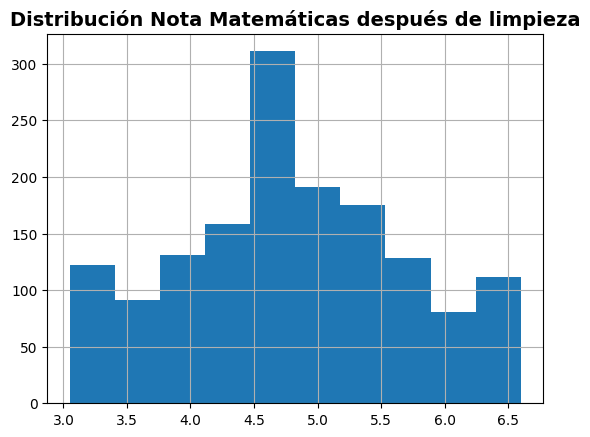

In [ ]:
data_clean['nota_matematicas'].hist()
plt.title('Distribución Nota Matemáticas después de limpieza', fontsize=14, fontweight="bold")
plt.show()